# BoW 기반 텍스트 분석 연습

1. 적절한 데이터셋을 찾거나 생성하고, 적절한 전처리를 진행한다. [01_preprocessing.ipynb]
2. TF-IDF Vectorizer를 이용하여 벡터화한다.
3. Cosine Similarity를 계산하여 입력된 문자열의 긍/부정을 판단한다.

만약 데이터 셋이 긍부정이 있는 데이터 셋이라면
cluster랑 similarity 결과값에 따라서 다시 한번 확인해보기?!

데이터 준비 -> 전처리 -> TF-IDF 벡터화 -> cos simil 계산 -> 긍부정 판단

감성분석이라 긍부정 데이터가 필요함 / 라벨 (긍정=1, 부정=0)

전처리: 특수문자 제거, 소문자(한국어라 의미없나?), 토큰화, 불용어 제거

TF-IDF 벡터화 , 입력문자 벡터화

cos simil 계산

긍부정 판단 argmax?



In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'  # Windows
mpl.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

# 1. 데이터셋 주소 설정 (인터넷에 있는 파일을 직접 가리킵니다)
url = "https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/naver_shopping.txt"

# 2. 데이터 불러오기 
# sep='\t': 데이터가 탭(Tab)으로 구분되어 있다는 뜻입니다.
# names: 데이터의 열(Column) 이름을 우리가 직접 정해줍니다.
df = pd.read_csv(url, sep='\t', names=['rating', 'content'])

# 3. 잘 들어왔는지 확인
print(df.head())

   rating                                            content
0       5                                            배공빠르고 굿
1       2                      택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2       5  아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3       2  선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4       5                  민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [ ]:
# 토큰화 + 전처리
from konlpy.tag import Okt

okt = Okt()
token = okt.morphs(df['content'][0])


In [20]:
# 불용어(stopwords) 제거
def load_ko_stopwords(filepath):
    with open(filepath, 'r', encoding='UTF-8') as f:
        return [line.strip() for line in f]
    
ko_stopwords = load_ko_stopwords('ko_stopwords.txt')

def tokenize(text):
    return [word for word, tag in okt.pos(text, norm=True, stem=True) if tag in ['Noun', 'Verb', 'Adjective'] and word not in ko_stopwords]

In [ ]:
tokenize_list = [tokenize(text) for text in df['content']]
df['tokenize_list'] = tokenize_list
# df 저장
df.to_csv('tokenized_data.csv', index=False)
df = pd.read_csv('tokenized_data.csv')

In [ ]:
# 불러오기 
df = pd.read_csv('tokenized_data.csv')

0                                        ['배공', '빠르다', '굿']
1              ['택배', '엉망', '용', '집', '밑', '층', '말', '놔두다']
2         ['아주', '좋다', '바지', '정말', '좋다', '개', '더', '구매',...
3         ['선물', '용', '받다', '전달', '하다', '하다', '상품', '이다'...
4         ['민트', '색상', '예쁘다', '옆', '손잡이', '거', '용', '도로'...
                                ...                        
199995                              ['장마', '런가', '달', '않다']
199996    ['다이슨', '케이스', '구매', '하다', '다이슨', '슈퍼소닉', '드라이...
199997             ['로드샾', '살다', '세배', '저렴하다', '자주', '용하다']
199998                     ['넘다', '이쁘다', '쎄다', '되다', '보이다']
199999    ['사용', '해보다', '않다', '제품', '써다', '본적', '없다', '자...
Name: tokenize_list, Length: 200000, dtype: str

In [9]:
df

,rating,content,tokenize_list
0,5,배공빠르고 굿,"['배공', '빠르다', '굿']"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"['택배', '엉망', '용', '집', '밑', '층', '말', '놔두다']"
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"['아주', '좋다', '바지', '정말', '좋다', '개', '더', '구매',..."
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"['선물', '용', '받다', '전달', '하다', '하다', '상품', '이다'..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"['민트', '색상', '예쁘다', '옆', '손잡이', '거', '용', '도로'..."
...,...,...,...
199995,2,장마라그런가!!! 달지않아요,"['장마', '런가', '달', '않다']"
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"['다이슨', '케이스', '구매', '하다', '다이슨', '슈퍼소닉', '드라이..."
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,"['로드샾', '살다', '세배', '저렴하다', '자주', '용하다']"
199998,5,넘이쁘고 쎄련되보이네요~,"['넘다', '이쁘다', '쎄다', '되다', '보이다']"


In [27]:
# TF-IDF 계산
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(  # 문자열로 저장된 리스트를 다시 리스트로 변환
    stop_words=ko_stopwords # 불용어 제거 추가
    )
tfidf_vecs = tfidf_vectorizer.fit_transform(df['tokenize_list'])
display(tfidf_vecs)
feature_names = tfidf_vectorizer.get_feature_names_out()
print(feature_names)

c:\Users\Playdata\miniconda3\envs\nlp_env\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['가서', '같은', '것과', '결과에', '결론을', '관계가', '관련이', '그런', '그럼에도', '그렇게', '그에', '그치지', '김에', '까닭에', '낫다', '년도', '논하지', '누가', '다시', '달려', '대로', '대해', '되는', '되다', '되어', '들면', '들자면', '듯하다', '따르는', '따름이다', '따지지', '때가', '만은', '만이', '만큼', '많은', '말하면', '말할것도', '몰라도', '몰랏다', '못하다', '미치다', '바꾸어서', '바꿔', '밖에', '방면으로', '보면', '보아', '부류의', '비길수', '비추어', '뿐만', '사람들', '상대적으로', '생각이다', '서술한바와같이', '쓰여', '아니다', '아니라', '안다', '안된다', '않고', '않기', '않는다면', '않다', '않다면', '않도록', '않으면', '알겠는가', '어쩔수', '어찌됏든', '없고', '없다', '예를', '외에', '요만한', '우에', '위에서', '이렇게', '이로', '이르다', '이와', '이유는', '인하여', '임에', '점에서', '정도에', '정도의', '종합한것과같이', '주저하지', '줄은', '지경이다', '틀림없다', '편이', '하고', '하기', '하기만', '하는', '하는것만', '하는것이', '하다', '하면', '하지', '한하다', '할수록', '함으로써', '해도', '해서는', '형식으로', '힘이'] not in stop_words.
  warnings.warn(


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1557637 stored elements and shape (200000, 35569)>

['가가' '가각' '가감' ... '힝힝' '힞들어' '힞싲']


In [ ]:
# 긍부정 라벨 있음 1~5까지. 1,2는 부정, 4,5는 긍정. 3은 중립으로 간주
def convert_label(score):
    if score >= 4:
        return 1
    elif score <= 2:
        return 0
    else:
        return None
df['label'] = df['rating'].apply(convert_label)
df = df.dropna()
print(df['label'].value_counts())

label
0    100037
1     99963
Name: count, dtype: int64


In [ ]:
# 감성 분석 시도
# 군집화
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,  # 군집(긍정과 부정)
    random_state=42
)
opinions_label = kmeans.fit_predict(tfidf_vecs)
df['opinions_label'] = opinions_label

In [30]:
centers = kmeans.cluster_centers_
print(centers.shape)

centroid_arg_idx = centers.argsort()[:, ::-1]  # tf-idf값이 높은순으로 index 정렬
idx_top_20 = centroid_arg_idx[:, :20]
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_names[idx_top_20]

(2, 35569)


array([['안되다', '하다', '자다', '고정', '되다', '그냥', '사용', '반품', '충전', '배송',
        '쓰다', '없다', '사다', '버리다', '오다', '제품', '교환', '받다', '구매', '좋다'],
       ['좋다', '하다', '배송', '재다', '자다', '먹다', '빠르다', '구매', '이다', '않다',
        '쓰다', '생각', '사용', '가격', '없다', '오다', '사다', '제품', '보다', '되다']],
      dtype=object)

In [ ]:
pd.crosstab(df["label"], df["opinions_label"], margins=True)
# cluster 1 ≈ 97%
# cluster 0 ≈ 3%
# 유의미 하지 않음

opinions_label,0,1,All
label,,,
0,4923,95114,100037
1,502,99461,99963
All,5425,194575,200000


In [34]:
# similarity 계산
hotel_idx = df[df['opinions_label'] == 1].index
print(hotel_idx)

# 첫 번째 리뷰를 기준 리뷰로 선정
base_idx = 1
df.iloc[base_idx]

Index([     0,      1,      2,      3,      4,      5,      7,      8,      9,
           10,
       ...
       199990, 199991, 199992, 199993, 199994, 199995, 199996, 199997, 199998,
       199999],
      dtype='int64', length=194575)


rating                                                       2
content                          택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
tokenize_list     ['택배', '엉망', '용', '집', '밑', '층', '말', '놔두다']
label                                                        0
opinions_label                                               1
Name: 1, dtype: object

In [35]:
from sklearn.metrics.pairwise import cosine_similarity

opinions_sim = cosine_similarity(tfidf_vecs[base_idx], tfidf_vecs)
opinions_sim

array([[0., 1., 0., ..., 0., 0., 0.]], shape=(1, 200000))

In [38]:
opinions_sorted_idx = opinions_sim.argsort()[:, ::-1]   # 내림차순 정렬
opinions_sorted_idx = opinions_sorted_idx[:, 1:]        # 자기자신 제외
opinions_sorted_idx = opinions_sorted_idx.reshape(-1)   # 1차원으로 변형

result_df = df.iloc[opinions_sorted_idx][['content', 'opinions_label']]
result_df

,content,opinions_label
153889,다른 곳에서 산 건 그냥 놔둬도 향이 진한데 이건 여러개를 놔둬도 향이 안나요 ㅠㅠ,1
197949,택배 회사 바꾸세요 다른동에 택배 놔두면 어떻게 찾습니까?,1
30674,사이즈가 안맞아서 사용못해요.. 교환 택배비가 더 나올거같아서 그냥 놔둡니다,1
66236,화면과 같이 왔네요? 배송기사는 설치도안하고 놔두고가고 엉망이네요 ㅡㅡ,1
105302,배송이 엉망 이에요,1
...,...,...
199988,양 엄청나요~많이 달지도 않고 맛있어요~,1
199987,꽃이3송이였는데 똑..부러졌더라구요ㅠ 선물한거라서..교환이어려워요ㅠ,1
199986,너무 맛있어요! 4명이 먹을거라 넉넉하게 샀다했는데 순식간에 없어집니다! 꼭 드셔보세요!,1
199985,별로에요 진짜 ㅠ 너무하네,1


In [ ]:
opinions_sim = opinions_sim.reshape(-1)
result_df['similarity'] = opinions_sim[opinions_sorted_idx]
result_df

,content,opinions_label,similarity
153889,다른 곳에서 산 건 그냥 놔둬도 향이 진한데 이건 여러개를 놔둬도 향이 안나요 ㅠㅠ,1,0.579722
197949,택배 회사 바꾸세요 다른동에 택배 놔두면 어떻게 찾습니까?,1,0.570798
30674,사이즈가 안맞아서 사용못해요.. 교환 택배비가 더 나올거같아서 그냥 놔둡니다,1,0.539174
66236,화면과 같이 왔네요? 배송기사는 설치도안하고 놔두고가고 엉망이네요 ㅡㅡ,1,0.519542
105302,배송이 엉망 이에요,1,0.508577
...,...,...,...
199988,양 엄청나요~많이 달지도 않고 맛있어요~,1,0.000000
199987,꽃이3송이였는데 똑..부러졌더라구요ㅠ 선물한거라서..교환이어려워요ㅠ,1,0.000000
199986,너무 맛있어요! 4명이 먹을거라 넉넉하게 샀다했는데 순식간에 없어집니다! 꼭 드셔보세요!,1,0.000000
199985,별로에요 진짜 ㅠ 너무하네,1,0.000000


### 코사인유사도 결과
결과값이 가장 높은 값이 0.58..? 뭔가 이상 재도전

의심 : 전처리 과정에서 뭔가 잘못 됐을 것으로 판단 그리고 tf-idf 벡터화도 문제 됐을 것이라 판단됨 파라미터 추가해볼까
<!--TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    min_df=3,
    max_df=0.8,
    ngram_range=(1,2)
)  -->


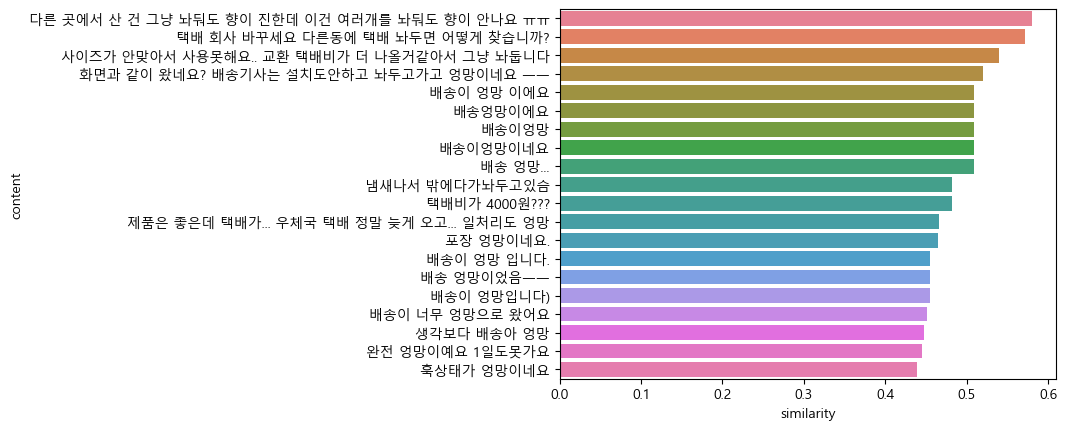

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='similarity', y='content', data=result_df.iloc[:20], hue='content')
plt.show()